In [32]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import glob
import os
from PIL import Image
from torchvision import transforms, datasets
import torchvision.models as models
import time
import copy
import matplotlib.pyplot as plt

In [2]:
CLASSES = {
    'garbage': 0,
    'paper': 1,
    'cardboard': 2, 
    'biological': 3, 
    'metal': 4, 
    'plastic': 5, 
    'green-glass': 6, 
    'brown-glass': 7, 
    'white-glass': 8, 
    'clothes': 9, 
    'shoes': 10, 
    'batteries': 11, 
    'trash': 12
}

In [12]:
transform = transforms.Compose([
    transforms.Resize((244, 244)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
dataset_folder = '/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification'
dataset = datasets.ImageFolder(root=dataset_folder, transform=transform)
print(dataset.class_to_idx)
print(len(dataset))

{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}
15515


In [17]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator = torch.Generator().manual_seed(42)
)

In [19]:
batch_size = 16
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers = 2,
    pin_memory = True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size = 1,
    shuffle = False,
    num_workers = 2,
    pin_memory = True,
)


Kích thước một lô ảnh (Batch): torch.Size([16, 3, 244, 244])
Kích thước một lô nhãn (Labels): torch.Size([16])
Ví dụ nhãn của 5 ảnh đầu tiên trong lô: [9, 4, 1, 4, 3]


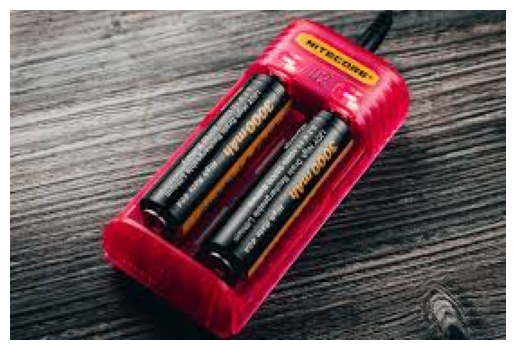

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [25]:
def get_models(model_name, num_classes = 12):
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        # EfficientNet dùng classifier[1] ở cuối, in_features = 1280
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == 'efficientnet_v2_s':
        model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    elif model_name == 'mobilenet_v3_large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        # MobileNetV3 dùng classifier[3] ở cuối, in_features = 1280
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        # ConvNeXt dùng classifier[2] ở cuối, in_features = 768
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"Model {model_name} doesn't exist")
    return model

In [28]:
def train_and_evaluate(model, model_name, train_loader, test_loader, criterion, optimizer, num_epochs=50, device='cuda'):
    model = model.to(device)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} - Model: {model_name}')
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)
        # --- EVALUATE ---
        model.eval()
        running_test_loss = 0.0
        running_test_corrects = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                running_test_loss += loss.item() * inputs.size(0)
                running_test_corrects += torch.sum(preds == labels.data)
        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        epoch_test_acc = running_test_corrects.double() / len(test_loader.dataset)
        print(f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
        print(f'Test Loss: {epoch_test_loss:.4f} Acc: {epoch_test_acc:.4f}\n')
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc.item())
        # Lưu lại mô hình tốt nhất dựa trên Test Accuracy
        if epoch_test_acc > best_acc:
            best_acc = epoch_test_acc
            best_model_wts = copy.deepcopy(model.state_dict())
    print(f'[{model_name}] Đạt Test Acc tốt nhất: {best_acc:.4f}')
    # Tải lại trọng số tốt nhất trước khi trả về
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), f'{model_name}_best.pth')
    return model, history

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
models_to_test = ['resnet50', 'efficientnet_b0', 'efficientnet_v2_s', 'mobilenet_v3_large', 'convnext_tiny'] 
all_results = {}
for model_name in models_to_test:
    print(f"================ {model_name} ================")
    # 1. Khởi tạo mô hình
    model = get_models(model_name, num_classes=12)
    # 2. Định nghĩa Bộ tối ưu hóa (Optimizer)
    # Với Transfer Learning, khuyên dùng Adam hoặc AdamW với lr nhỏ (1e-4) để tránh phá hỏng trọng số cũ
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    # 3. Tiến hành huấn luyện
    _, history = train_and_evaluate(
        model=model, 
        model_name=model_name, 
        train_loader=train_loader, 
        test_loader=test_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=5,
        device=device
    )
    # 4. Lưu lại lịch sử để so sánh đồ thị
    all_results[model_name] = history

================ resnet50 ================
Epoch 1/5 - Model: resnet50
Train Loss: 0.4304 Acc: 0.8751
Test Loss: 0.1038 Acc: 0.9681

Epoch 2/5 - Model: resnet50
Train Loss: 0.1409 Acc: 0.9577
Test Loss: 0.0951 Acc: 0.9681

Epoch 3/5 - Model: resnet50
Train Loss: 0.0961 Acc: 0.9714
Test Loss: 0.0960 Acc: 0.9697

Epoch 4/5 - Model: resnet50
Train Loss: 0.0797 Acc: 0.9747
Test Loss: 0.0840 Acc: 0.9729

Epoch 5/5 - Model: resnet50
Train Loss: 0.0570 Acc: 0.9817
Test Loss: 0.0925 Acc: 0.9729

[resnet50] Đạt Test Acc tốt nhất: 0.9729
================ efficientnet_b0 ================
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


Epoch 1/5 - Model: efficientnet_b0
Train Loss: 0.5843 Acc: 0.8439
Test Loss: 0.1386 Acc: 0.9581

Epoch 2/5 - Model: efficientnet_b0
Train Loss: 0.1917 Acc: 0.9401
Test Loss: 0.0942 Acc: 0.9716

Epoch 3/5 - Model: efficientnet_b0
Train Loss: 0.1176 Acc: 0.9636
Test Loss: 0.0820 Acc: 0.9742

Epoch 4/5 - Model: efficientnet_b0
Train Loss: 0.0893 Acc: 0.9712
Test Loss: 0.0684 Acc: 0.9810

Epoch 5/5 - Model: efficientnet_b0
Train Loss: 0.0674 Acc: 0.9784
Test Loss: 0.0770 Acc: 0.9787

[efficientnet_b0] Đạt Test Acc tốt nhất: 0.9810
================ efficientnet_v2_s ================
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 194MB/s]


Epoch 1/5 - Model: efficientnet_v2_s
Train Loss: 0.3786 Acc: 0.8978
Test Loss: 0.0792 Acc: 0.9752

Epoch 2/5 - Model: efficientnet_v2_s
Train Loss: 0.1084 Acc: 0.9677
Test Loss: 0.0883 Acc: 0.9742

Epoch 3/5 - Model: efficientnet_v2_s
Train Loss: 0.0763 Acc: 0.9772
Test Loss: 0.0764 Acc: 0.9787

Epoch 4/5 - Model: efficientnet_v2_s
Train Loss: 0.0571 Acc: 0.9832
Test Loss: 0.0906 Acc: 0.9752

Epoch 5/5 - Model: efficientnet_v2_s
Train Loss: 0.0517 Acc: 0.9841
Test Loss: 0.0711 Acc: 0.9803

[efficientnet_v2_s] Đạt Test Acc tốt nhất: 0.9803
================ mobilenet_v3_large ================
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 148MB/s] 


Epoch 1/5 - Model: mobilenet_v3_large
Train Loss: 0.4427 Acc: 0.8674
Test Loss: 0.1535 Acc: 0.9497

Epoch 2/5 - Model: mobilenet_v3_large
Train Loss: 0.1483 Acc: 0.9554
Test Loss: 0.1093 Acc: 0.9652

Epoch 3/5 - Model: mobilenet_v3_large
Train Loss: 0.0963 Acc: 0.9689
Test Loss: 0.1213 Acc: 0.9594

Epoch 4/5 - Model: mobilenet_v3_large
Train Loss: 0.0658 Acc: 0.9783
Test Loss: 0.1041 Acc: 0.9652

Epoch 5/5 - Model: mobilenet_v3_large
Train Loss: 0.0614 Acc: 0.9803
Test Loss: 0.1192 Acc: 0.9668

[mobilenet_v3_large] Đạt Test Acc tốt nhất: 0.9668
================ convnext_tiny ================
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 201MB/s] 


Epoch 1/5 - Model: convnext_tiny
Train Loss: 0.2553 Acc: 0.9276
Test Loss: 0.0936 Acc: 0.9700

Epoch 2/5 - Model: convnext_tiny
Train Loss: 0.0725 Acc: 0.9786
Test Loss: 0.0956 Acc: 0.9697

Epoch 3/5 - Model: convnext_tiny
Train Loss: 0.0504 Acc: 0.9845
Test Loss: 0.0881 Acc: 0.9729

Epoch 4/5 - Model: convnext_tiny
Train Loss: 0.0407 Acc: 0.9866
Test Loss: 0.0856 Acc: 0.9762

Epoch 5/5 - Model: convnext_tiny
Train Loss: 0.0323 Acc: 0.9901
Test Loss: 0.1850 Acc: 0.9504

[convnext_tiny] Đạt Test Acc tốt nhất: 0.9762


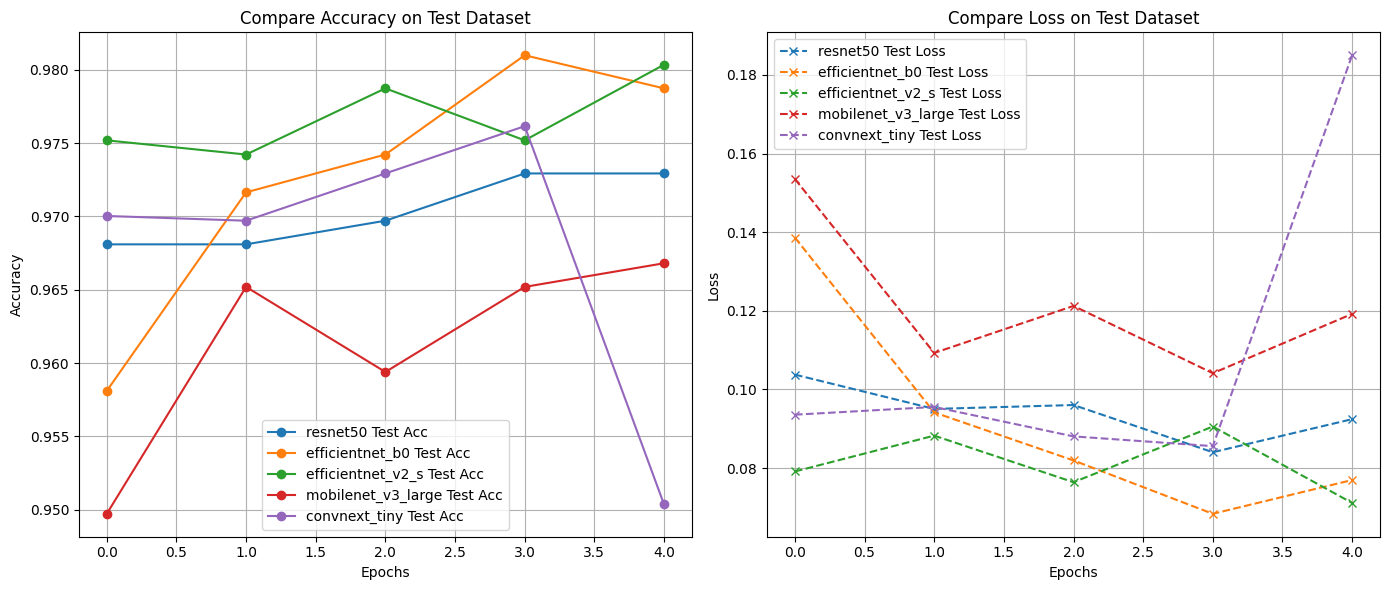

In [33]:
plt.figure(figsize=(14, 6))
# Đồ thị so sánh Test Accuracy
plt.subplot(1, 2, 1)
for model_name, history in all_results.items():
    plt.plot(history['test_acc'], label=f'{model_name} Test Acc', linestyle='-', marker='o')
plt.title('Compare Accuracy on Test Dataset')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# Đồ thị so sánh Test Loss
plt.subplot(1, 2, 2)
for model_name, history in all_results.items():
    plt.plot(history['test_loss'], label=f'{model_name} Test Loss', linestyle='--', marker='x')
plt.title('Compare Loss on Test Dataset')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('model_comparison.png') # Lưu lại đồ thị kết quả
plt.show()